# Coursera Course Recommendation Engine

## Objective

The goal of this project is to build a course recommendation engine using the Coursera course dataset.

The project will compare:

1. Baseline Recommendation System
   - Popularity Based Recommendations
   - Category Based Recommendations

2. Content-Based Recommendation System
   - TF-IDF Vectorization
   - Cosine Similarity

The performance of the recommendation engine will be evaluated against the baseline model to determine whether personalized recommendations improve recommendation quality.

Dataset:
- 9,595 Coursera Courses
- 13 Features
- Course Metadata
- Skills
- Learning Outcomes
- Ratings
- Reviews
- Institutions

# Step 1: Load Required Libraries

In this section we import all required libraries for:

- Data Cleaning
- Data Analysis
- Visualization
- Feature Engineering
- Recommendation Modeling

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data\CourseraDataset-Unclean.csv")

In [3]:
df.sample(5)

,Course Title,Rating,Level,Duration,Schedule,Review,What you will learn,Skill gain,Modules,Instructor,Offered By,Keyword,Course Url
8961,Econometrics for Economists and Finance Practi...,3.2,Intermediate level,3 months at 10 hours a week,Flexible schedule,30 reviews,The Ordinary Least Squares methodHow to perfor...,['Calculate and perform the various diagnostic...,"['The Classical Linear Regression Model', 'Hyp...",['Dr Leone Leonida'],['Queen Mary University of London'],Social Sciences,https://www.coursera.org/specializations/econo...
4066,Genome Sequencing (Bioinformatics II),4.6,Intermediate level,17 hours (approximately),Flexible schedule,305 reviews,NaN,"['Algorithms', 'Python Programming', 'Whole Ge...","['Week 1: Introduction to Genome Sequencing', ...","['Pavel Pevzner', 'Phillip Compeau']",['University of California San Diego'],Health,https://www.coursera.org/learn/genome-sequencing
8235,Differential Calculus through Data and Modelin...,4.8,Intermediate level,1 months at 10 hours a week,Flexible schedule,150 reviews,Model data with both single and multivariable ...,"['Data Analysis', 'function analysis', 'Mathem...",['Calculus through Data & Modeling: Precalculu...,"['Joseph W. Cutrone, PhD']",['Johns Hopkins University'],Social Sciences,https://www.coursera.org/specializations/diffe...
22,"Herencia negra, aplicación de ritmos afroperuanos",NaN,Beginner level,Approx. 16 hours to complete,Flexible schedule,NaN,NaN,"['Musical Notation', 'Musical Composition']","['Bienvenida al curso', 'Panorama de la cultur...",['Javier Lazo Figueroa'],['Pontificia Universidad Católica del Perú'],Arts and Humanities,https://www.coursera.org/learn/aplicacion-ritm...
6525,Cultural intelligence: Become a global citizen,4.7,NaN,18 hours (approximately),Flexible schedule,152 reviews,NaN,[],"['Globalisation of people', 'Affinities and di...",['Professor Fei Guo'],['Macquarie University'],Personal Development,https://www.coursera.org/learn/cultural-intell...


# Information about the dataset:

- There 9595 rows in the dataset.
- There are 13 columns in the dataset.


# Columns:
- 'Course Title': Data type is text/object. Doesn't contain missing values.
- 'Rating': Data type is numeric. Contain missing values.
- 'Level': Data type is text/object. Contain missing values.
- 'Duration': Data type is text/object. Contain missing values.
- 'Schedule': Data type is text/object. Contain missing values.
- 'Review': Data type is text/object. Contain missing values.
- 'What you will learn': Data type is text/object. Contain missing values.
- 'Skill gain': Data type is text/object. Doesn't contain missing values.
- 'Modules': Data type is text/object. Doesn't contain missing values.
- 'Instructor': Data type is text/object. Doesn't contain missing values.
- 'Offered By': Data type is text/object. Doesn't contain missing values.
- 'Keyword': Data type is text/object. Doesn't contain missing values.
- 'Course Url': Data type is text/object. Doesn't contain missing values.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9595 entries, 0 to 9594
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Course Title         9595 non-null   object 
 1   Rating               8156 non-null   float64
 2   Level                8330 non-null   object 
 3   Duration             9333 non-null   object 
 4   Schedule             8912 non-null   object 
 5   Review               8152 non-null   object 
 6   What you will learn  4984 non-null   object 
 7   Skill gain           9595 non-null   object 
 8   Modules              9595 non-null   object 
 9   Instructor           9595 non-null   object 
 10  Offered By           9595 non-null   object 
 11  Keyword              9595 non-null   object 
 12  Course Url           9595 non-null   object 
dtypes: float64(1), object(12)
memory usage: 974.6+ KB


In [5]:
df.shape

(9595, 13)

In [6]:
df.columns.tolist()

['Course Title',
 'Rating',
 'Level',
 'Duration',
 'Schedule',
 'Review',
 'What you will learn',
 'Skill gain',
 'Modules',
 'Instructor',
 'Offered By',
 'Keyword',
 'Course Url']

In [7]:
df.isnull().sum()

Course Title              0
Rating                 1439
Level                  1265
Duration                262
Schedule                683
Review                 1443
What you will learn    4611
Skill gain                0
Modules                   0
Instructor                0
Offered By                0
Keyword                   0
Course Url                0
dtype: int64

In [8]:
df[df['What you will learn'].isna()][['Course Title','Offered By']].head(20)

,Course Title,Offered By
0,Fashion as Design,['The Museum of Modern Art']
1,Modern American Poetry,['University of Illinois at Urbana-Champaign']
2,Pixel Art for Video Games,['Michigan State University']
3,Distribución digital de la música independiente,['SAE Institute México']
6,The Politics of Skepticism,['Erasmus University Rotterdam']
7,Становлення сучасної України,['Yale University']
8,Exploring Beethoven's Piano Sonatas Part 4,['Curtis Institute of Music']
9,悖论：思维的魔方,['Peking University']
10,拍摄：像剪辑师一样拍摄,['Fudan University']
11,In the Studio: Postwar Abstract Painting,['The Museum of Modern Art']


In [9]:
df[df['What you will learn'].isna()]['Offered By'].value_counts().head(20)

Offered By
['University of Illinois at Urbana-Champaign']            196
['University of Pennsylvania']                            173
['Johns Hopkins University']                              145
['Universidad Nacional Autónoma de México']               133
['University of Colorado System']                         126
['University of California San Diego']                     95
['University of California, Irvine']                       92
['Rice University']                                        90
['Duke University']                                        88
['Yale University']                                        86
['Universitat Autònoma de Barcelona']                      85
['University of Geneva']                                   82
['Google']                                                 77
['Arizona State University']                               66
['Stanford University']                                    60
['National Taiwan University']                             

In [10]:
df.describe(include='all')

,Course Title,Rating,Level,Duration,Schedule,Review,What you will learn,Skill gain,Modules,Instructor,Offered By,Keyword,Course Url
count,9595,8156.000000,8330,9333,8912,8152,4984,9595,9595,9595,9595,9595,9595
unique,6392,NaN,3,215,1,1865,3317,3985,5691,3587,395,10,6404
top,Business Analytics Specialization,NaN,Beginner level,1 months at 10 hours a week,Flexible schedule,10 reviews,Model data with both single and multivariable ...,[],['Learn step-by-step'],['Google Cloud Training'],['Coursera Project Network'],Social Sciences,https://www.coursera.org/learn/human-needs
freq,9,NaN,5689,718,8912,76,9,3090,584,296,563,1896,7
mean,NaN,4.651533,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,0.240674,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,1.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,4.600000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,4.700000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,4.800000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df['Course Title'].duplicated().sum()

np.int64(3203)

In [12]:
df['Course Url'].duplicated().sum()

np.int64(3191)



The dataset contains a large number of duplicate course titles and URLs.

Before removing duplicates, we inspect duplicate records to determine whether they are exact duplicates or contain additional information that should be preserved.

In [13]:
duplicate_urls = df[df['Course Url'].duplicated(keep=False)]

duplicate_urls[['Course Title','Course Url']].head(20)

,Course Title,Course Url
12,Philosophy of Science,https://www.coursera.org/learn/philosophy-of-s...
25,Overcoming Challenges in Self and Society,https://www.coursera.org/learn/overcoming-chal...
27,"Internal Displacement, Conflict and Protection",https://www.coursera.org/learn/internal-displa...
28,"Health, Society, and Wellness in COVID-19 Times",https://www.coursera.org/learn/health-society-...
30,Graphic Design Specialization,https://www.coursera.org/specializations/graph...
31,UI / UX Design Specialization,https://www.coursera.org/specializations/ui-ux...
33,Modern and Contemporary Art and Design Special...,https://www.coursera.org/specializations/moder...
34,Game Design: Art and Concepts Specialization,https://www.coursera.org/specializations/game-...
37,The Business of Music Production Specialization,https://www.coursera.org/specializations/busin...
40,Fundamentals of Graphic Design,https://www.coursera.org/learn/fundamentals-of...


In [14]:
duplicate_urls.shape

(5283, 13)

In [15]:
df.duplicated().sum()

np.int64(900)

In [16]:
df['Schedule'].nunique()

1

# Removing Low Information Features

The Schedule column contains only a single value
("Flexible schedule") across the dataset.

Since the feature has no variance and provides no
recommendation signal it is removed


In [17]:
df.drop(columns=['Schedule'], inplace=True)

In [18]:
duplicate_urls.groupby('Course Url').size().sort_values(ascending=False).head(10)

Course Url
https://www.coursera.org/learn/human-needs                                                    7
https://www.coursera.org/specializations/direccion-y-gestion-de-negocios                      6
https://www.coursera.org/specializations/effective-business-communication                     6
https://www.coursera.org/specializations/ai-healthcare                                        6
https://www.coursera.org/professional-certificates/certified-ethical-emerging-technologist    6
https://www.coursera.org/specializations/data-analytics-business                              6
https://www.coursera.org/specializations/information-systems                                  6
https://www.coursera.org/learn/cyber-conflicts                                                6
https://www.coursera.org/learn/introduction-psychology                                        6
https://www.coursera.org/learn/moral-politics                                                 6
dtype: int64

In [19]:
duplicate_urls[
    duplicate_urls['Course Url'] ==
    duplicate_urls['Course Url'].value_counts().index[0]
]

,Course Title,Rating,Level,Duration,Schedule,Review,What you will learn,Skill gain,Modules,Instructor,Offered By,Keyword,Course Url
1948,The Arts and Science of Relationships: Underst...,4.5,Beginner level,Approx. 31 hours to complete,Flexible schedule,"1,635 reviews",NaN,"['Psychology', 'Assertiveness', 'Communication...","['Module 1 - Relationships in Our Lives', 'Mod...",['A. Ka Tat Tsang'],['University of Toronto'],Computer Science,https://www.coursera.org/learn/human-needs
2648,The Arts and Science of Relationships: Underst...,4.5,Beginner level,Approx. 31 hours to complete,Flexible schedule,"1,635 reviews",NaN,"['Psychology', 'Assertiveness', 'Communication...","['Module 1 - Relationships in Our Lives', 'Mod...",['A. Ka Tat Tsang'],['University of Toronto'],DataScience,https://www.coursera.org/learn/human-needs
3518,The Arts and Science of Relationships: Underst...,4.5,Beginner level,Approx. 31 hours to complete,Flexible schedule,"1,635 reviews",NaN,"['Psychology', 'Assertiveness', 'Communication...","['Module 1 - Relationships in Our Lives', 'Mod...",['A. Ka Tat Tsang'],['University of Toronto'],Health,https://www.coursera.org/learn/human-needs
5794,The Arts and Science of Relationships: Underst...,4.5,Beginner level,Approx. 31 hours to complete,Flexible schedule,"1,635 reviews",NaN,"['Psychology', 'Assertiveness', 'Communication...","['Module 1 - Relationships in Our Lives', 'Mod...",['A. Ka Tat Tsang'],['University of Toronto'],Math and Logic,https://www.coursera.org/learn/human-needs
5901,The Arts and Science of Relationships: Underst...,4.5,Beginner level,Approx. 31 hours to complete,Flexible schedule,"1,635 reviews",NaN,"['Psychology', 'Assertiveness', 'Communication...","['Module 1 - Relationships in Our Lives', 'Mod...",['A. Ka Tat Tsang'],['University of Toronto'],Personal Development,https://www.coursera.org/learn/human-needs
7715,The Arts and Science of Relationships: Underst...,4.5,Beginner level,Approx. 31 hours to complete,Flexible schedule,"1,635 reviews",NaN,"['Psychology', 'Assertiveness', 'Communication...","['Module 1 - Relationships in Our Lives', 'Mod...",['A. Ka Tat Tsang'],['University of Toronto'],Social Sciences,https://www.coursera.org/learn/human-needs
8711,The Arts and Science of Relationships: Underst...,4.5,Beginner level,Approx. 31 hours to complete,Flexible schedule,"1,635 reviews",NaN,"['Psychology', 'Assertiveness', 'Communication...","['Module 1 - Relationships in Our Lives', 'Mod...",['A. Ka Tat Tsang'],['University of Toronto'],Social Sciences,https://www.coursera.org/learn/human-needs


In [20]:
cols_to_check = [
    'Course Title',
    'Rating',
    'Level',
    'Duration',
    'Review',
    'What you will learn',
    'Skill gain',
    'Modules',
    'Instructor',
    'Offered By',
    'Course Url'
]

same_except_keyword = (
    df.groupby('Course Url')[cols_to_check]
      .nunique()
      .max(axis=1)
)

print((same_except_keyword == 1).mean())

0.9509681449094316


# Consolidating Duplicate Courses

Many courses appear multiple times because they are assigned to multiple keyword categories.

To avoid recommendation bias, duplicate courses are merged into a single record while preserving all associated categories.

In [21]:
group_cols = [
    'Course Title',
    'Rating',
    'Level',
    'Duration',
    'Review',
    'What you will learn',
    'Skill gain',
    'Modules',
    'Instructor',
    'Offered By',
    'Course Url'
]

df_clean = (
    df.groupby(group_cols, dropna=False)['Keyword']
      .apply(lambda x: list(set(x)))
      .reset_index()
)

df_clean.shape

(6720, 12)

## Duplicate Course Consolidation

Investigation revealed that approximately 95% of duplicate URLs represented the same course repeated across multiple keyword categories.

To prevent recommendation bias, duplicate courses were consolidated into a single record while preserving all associated keyword categories.

Dataset Size:

- Original Records: 9,595
- Clean Records: 6,720
- Removed Duplicate Representations: 2,875

In [22]:
df_clean.sample(5)

,Course Title,Rating,Level,Duration,Review,What you will learn,Skill gain,Modules,Instructor,Offered By,Course Url,Keyword
3199,Human Predicament Complex Modeling,4.4,Beginner level,1.5 hours,12 reviews,Be introduced to a framework to understand the...,"['analysis', 'Complex Modeling', 'Storytelling...",['Learn step-by-step'],['Danilo Oliveira Vaz'],['Coursera Project Network'],https://www.coursera.org/projects/predicament-...,[Physical Science and Engineering]
3114,Healthy and Sustainable Foods,NaN,Intermediate level,16 hours (approximately),NaN,Assess nutritional performance and sustainabil...,"['Environmental Impact Assessment', 'Sustainab...",['Introduction to Healthy and Sustainable Food...,['Olivier Jolliet'],['University of Michigan'],https://www.coursera.org/learn/healthy-sustain...,[Health]
6644,微影人的自我修养,4.7,NaN,Approx. 13 hours to complete,47 reviews,NaN,[],"['绪论：微影人的自我修养', '亲临微电影创作现场', '勤修微影人观念', '勤养微电影...",['许 肖潇'],['Fudan University'],https://www.coursera.org/learn/wei-dian-ying,[Arts and Humanities]
4465,Mind Control: Managing Your Mental Health Duri...,4.8,Beginner level,Approx. 2 hours to complete,"8,573 reviews",NaN,[],['The Machinery Underlying Anxiety and How to ...,['Steve Joordens'],['University of Toronto'],https://www.coursera.org/learn/manage-health-c...,"[Health, Arts and Humanities]"
3588,Introduction to Business Analytics and Informa...,4.7,Beginner level,1 months at 10 hours a week,46 reviews,Conceive new ways to leverage analytics to bus...,"['Monetization', 'Infonomics', 'Business Analy...","['Business Analytics Executive Overview', 'Inf...",['Douglas B. Laney'],['University of Illinois at Urbana-Champaign'],https://www.coursera.org/specializations/analy...,"[Business, DataScience, Computer Science]"


## Post-Consolidation Duplicate Analysis

After consolidating courses, a duplicate audit was performed using both Course Title and Course URL.

The analysis identified:

- 328 duplicate course titles
- 316 duplicate course URLs

Since Course URL uniquely identifies a Coursera course, duplicate URLs were treated as true duplicates. The difference between duplicate titles and duplicate URLs indicates that some courses share the same title while representing distinct courses.

To ensure each course appears only once, a final deduplication step was performed using Course URL as the unique identifier.

In [23]:
df_clean['Course Title'].duplicated().sum()

np.int64(328)

In [24]:
df_clean['Course Url'].duplicated().sum()

np.int64(316)

In [25]:
print("Before:", df_clean.shape)

df_clean = (
    df_clean
    .drop_duplicates(
        subset='Course Url',
        keep='first'
    )
    .reset_index(drop=True)
)

print("After:", df_clean.shape)

Before: (6720, 12)
After: (6404, 12)


In [26]:
print(
    "Duplicate URLs:",
    df_clean['Course Url'].duplicated().sum()
)

print(
    "Duplicate Titles:",
    df_clean['Course Title'].duplicated().sum()
)

Duplicate URLs: 0
Duplicate Titles: 16


## Deduplication Results

After removing duplicate records based on Course URL:

- Duplicate URLs reduced from 316 to 0.
- Duplicate course titles reduced from 328 to 16.

The remaining duplicate titles correspond to courses that share the same title but have different Course URLs, indicating they are distinct courses rather than duplicate records.

The final dataset therefore contains one record per unique course URL and is suitable for recommendation modeling.

# Duration Standardization

Course duration is stored in multiple formats.

Examples:

- 42 hours (approximately)
- Approx. 21 hours to complete
- 3 months at 10 hours a week

For recommendation modeling, duration must be represented as a numerical feature.

All durations are converted into estimated total learning hours.

In [27]:
import re
import numpy as np

def parse_duration(duration):

    if pd.isna(duration):
        return np.nan

    duration = str(duration).lower()

    # Month-based courses
    if "month" in duration:

        numbers = re.findall(r'\d+', duration)

        if len(numbers) >= 2:
            months = int(numbers[0])
            hours_per_week = int(numbers[1])

            return months * 4 * hours_per_week

    # Hour-based courses
    numbers = re.findall(r'\d+', duration)

    if len(numbers) >= 1:
        return int(numbers[0])

    return np.nan

In [28]:
df_clean['duration_hours'] = df_clean['Duration'].apply(parse_duration)

In [29]:
df_clean.sample(10)

,Course Title,Rating,Level,Duration,Review,What you will learn,Skill gain,Modules,Instructor,Offered By,Course Url,Keyword,duration_hours
5686,The Finite Element Method for Problems in Physics,4.6,Intermediate level,Approx. 61 hours to complete,530 reviews,Become familiar with the finite element method...,"['Finite Differences', 'C++', 'C Sharp (C#) (P...","['1', '2', '3', '4', '5', '6', '7', '8', '9', ...","['Krishna Garikipati, Ph.D.']",['University of Michigan'],https://www.coursera.org/learn/finite-element-...,"[Physical Science and Engineering, DataScience...",61.0
2591,Game Design and Development 1: 2D Shooter,4.7,Beginner level,14 hours (approximately),434 reviews,NaN,"['Game Making', 'Unity', 'Video Game Developme...","['From Game Player to Game Developer', 'Unders...",['Brian Winn'],['Michigan State University'],https://www.coursera.org/learn/game-design-and...,[Computer Science],14.0
4665,Power Electronics Specialization,4.8,Intermediate level,2 months at 10 hours a week,"3,066 reviews",NaN,['Understand the fundamentals of magnetic comp...,"['Introduction to Power Electronics', 'Convert...",['Dr. Robert Erickson'],['University of Colorado Boulder'],https://www.coursera.org/specializations/power...,"[Physical Science and Engineering, DataScience]",80.0
1183,Computational Thinking for K-12 Educators Caps...,NaN,Beginner level,11 hours (approximately),NaN,NaN,[],"['Capstone: Week 1', 'Capstone: Week 2', 'Caps...",['Beth Simon'],['University of California San Diego'],https://www.coursera.org/learn/computational-t...,[Math and Logic],11.0
3031,How to Network: Leading Yourself to Lead Others,4.5,Beginner level,Approx. 25 hours to complete,17 reviews,Build a networking mindset.Create your own act...,"['Personal Branding', 'Business', 'Relationshi...","['The Connection Between Leadership, Purpose a...",['Klementina X. Sula'],['University of Michigan'],https://www.coursera.org/learn/how-to-network,[Personal Development],25.0
1649,Data-Driven Leadership Skills Course 1: Leader...,NaN,Intermediate level,11 hours (approximately),NaN,"Critically evaluate, with particular reference...","['Data-Informed Decision-Making', 'Agile Manag...","['The Leadership Legacy', 'The Death of Leader...",['Matt Offord'],['University of Glasgow '],https://www.coursera.org/learn/data-driven-lea...,[Personal Development],11.0
6082,Wharton Business and Financial Modeling Capstone,4.6,NaN,13 hours (approximately),474 reviews,NaN,"['Summary Statistics', 'Financial Modeling', '...","['Getting Started', 'Steps 1 and 2: Yahoo Fina...","['Don Huesman', 'Richard Lambert', 'Richard Wa...",['University of Pennsylvania'],https://www.coursera.org/learn/wharton-busines...,[Business],13.0
4181,Mental Health and Resilience for Healthcare Wo...,4.8,Beginner level,Approx. 5 hours to complete,333 reviews,NaN,['Using a schedule to empower ones mental well...,"['Introduction and Welcome', 'Understanding an...","['Steve Joordens', 'Heather Gordon']",['University of Toronto'],https://www.coursera.org/learn/health-resilien...,[Health],5.0
2536,Fundamentals of Materials Science,4.6,Intermediate level,Approx. 20 hours to complete,144 reviews,NaN,[],"['Week 1', 'Week 2', 'Week 3', 'Week 4', 'Week...","['Qiang Guo', 'Kolan M. Reddy', 'Liu Jing']",['Shanghai Jiao Tong University'],https://www.coursera.org/learn/fundamentals-of...,[Physical Science and Engineering],20.0
2936,Health Systems Development Specialization,4.8,Beginner level,2 months at 10 hours a week,136 reviews,NaN,[],['Health Systems Development: Introduction to ...,['Dr Sondus Hassounah'],['Imperial College London'],https://www.coursera.org/specializations/healt...,[Health],80.0


## Convert Review Text into Numerical Review Count

The Review column contains textual review counts such as
"263 reviews" and "25,911 reviews".

For recommendation modeling, these values are converted into
numerical review counts.

In [30]:
import re
import numpy as np

def extract_reviews(text):

    if pd.isna(text):
        return np.nan

    match = re.search(r'[\d,]+', str(text))

    if match:
        return int(match.group().replace(',', ''))

    return np.nan

df_clean['review_count'] = df_clean['Review'].apply(extract_reviews)

In [31]:
df_clean['review_count'] = (
    df_clean['review_count']
    .fillna(0)
    .astype(int)
)

# Missing Value Treatment

Several features contain missing values.

Different imputation strategies are used depending on the nature of the variable:

- Rating → Median
- Level → Mode
- Review Count → 0
- Learning Outcomes → Empty String
- Duration Hours → Median

These choices preserve data while minimizing bias.

In [32]:
df_clean['Rating'] = pd.to_numeric(
    df_clean['Rating'],
    errors='coerce'
)

In [33]:
df_clean['Rating'] = ( 
    df_clean['Rating'].fillna(df_clean['Rating'].median()).astype(float)
)

In [34]:
df_clean['Level'] = (
    df_clean['Level']
    .fillna(df_clean['Level'].mode()[0])
)

In [35]:
df_clean['What you will learn'] = (
    df_clean['What you will learn'].fillna('')
)

In [36]:
df_clean['review_count'] = (
    df_clean['review_count'].fillna(0).astype(int)
)

In [37]:
df_clean['duration_hours'] =(
    df_clean['duration_hours'].fillna(df_clean['duration_hours'].median()).round().astype(int)
)

In [38]:
df_clean.isnull().sum().sort_values(ascending=False)

Review                 1252
Duration                228
Rating                    0
Course Title              0
Level                     0
What you will learn       0
Skill gain                0
Modules                   0
Instructor                0
Offered By                0
Course Url                0
Keyword                   0
duration_hours            0
review_count              0
dtype: int64

In [39]:
df_clean.sample(5)

,Course Title,Rating,Level,Duration,Review,What you will learn,Skill gain,Modules,Instructor,Offered By,Course Url,Keyword,duration_hours,review_count
2841,Google UX Design Professional Certificate,4.6,Beginner level,5 months at 10 hours a week,76 reviews,Le processus de conception : être en empathie ...,"['Tests de la facilité d’utilisation', 'Protot...",['Bases de la conception Expérience Utilisateu...,['Google Career Certificates'],['Google'],https://www.coursera.org/professional-certific...,"[DataScience, Computer Science]",200,76
6170,Çok değişkenli Fonksiyon II: Uygulamalar / Mul...,4.6,Beginner level,Approx. 21 hours to complete,13 reviews,,[],"[""Multivar 1'in Özeti, Dairesel Koordinatlarda...",['Attila Aşkar'],['Koç University'],https://www.coursera.org/learn/calculus-difera...,[Math and Logic],21,13
2788,Google Cloud Compute and Scalability for AWS P...,4.7,Intermediate level,3 hours (approximately),NaN,Create and configure a Compute Engine instance...,[],"[' Virtual Machines in Google Cloud', 'Load Ba...",['Google Cloud Training'],['Google Cloud'],https://www.coursera.org/learn/google-cloud-co...,[Information Technology],3,0
2742,Global Environmental Management,4.7,Intermediate level,Approx. 13 hours to complete,"1,964 reviews",,"['Urban Planning', 'Water Resource Development...","['WEEK/MODULE 1: Global Trends', 'WEEK/MODULE ...","['Steffen Foss Hansen', 'Henrik Bregnhøj']",['Technical University of Denmark (DTU)'],https://www.coursera.org/learn/global-environm...,"[Social Sciences, Physical Science and Enginee...",13,1964
4358,Natural Language Processing in TensorFlow,4.6,Intermediate level,24 hours (approximately),"6,363 reviews",Build natural language processing systems usin...,"['RNNs', 'Tensorflow', 'Machine Learning', 'To...","['Sentiment in text', ' Word Embeddings ', 'Se...",['Laurence Moroney'],['DeepLearning.AI'],https://www.coursera.org/learn/natural-languag...,"[DataScience, Computer Science]",24,6363


# Exploratory Data Analysis (EDA)

Before building recommendation models, exploratory analysis is performed to understand:

- Course distributions
- Ratings
- Skills
- Institutions
- Categories
- Duration patterns

These insights will guide feature engineering and model design.

# Dataset Overview

In [40]:
print("Number of Courses:", len(df_clean))

print("Unique Institutions:",
      df_clean['Offered By']
      .apply(lambda x: x[0] if len(x)>0 else "Unknown")
      .nunique())

print("Unique Skills:",
      len(set(
          skill
          for skills in df_clean['Skill gain']
          for skill in skills
      )))

Number of Courses: 6404
Unique Institutions: 1
Unique Skills: 339


# Rating Distribution

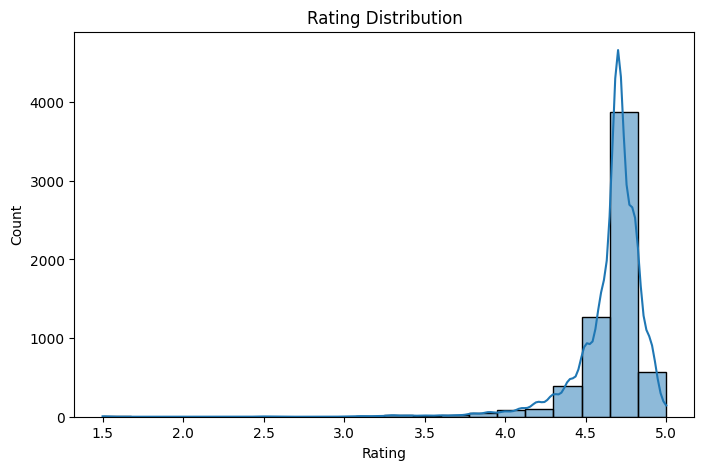

In [41]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_clean['Rating'],
    bins=20,
    kde=True
)

plt.title("Rating Distribution")
plt.show()

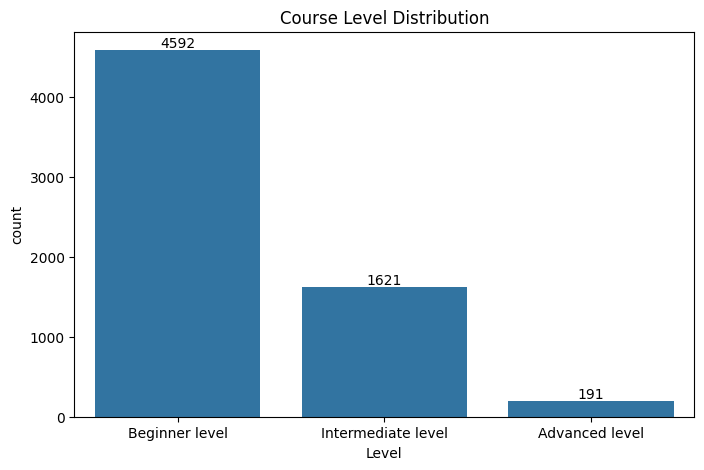

In [42]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df_clean,
    x='Level',
    order=df_clean['Level'].value_counts().index
)
ax.bar_label(ax.containers[0])

plt.title("Course Level Distribution")
plt.show()

In [43]:
from collections import Counter

keyword_counter = Counter()

for kws in df_clean['Keyword']:
    keyword_counter.update(kws)

keyword_df = (
    pd.DataFrame(
        keyword_counter.items(),
        columns=['Keyword','Count']
    )
    .sort_values(
        'Count',
        ascending=False
    )
)

keyword_df

,Keyword,Count
5,Information Technology,974
1,Health,961
7,Personal Development,959
2,Business,941
0,Social Sciences,927
6,Computer Science,925
4,DataScience,904
8,Physical Science and Engineering,787
9,Arts and Humanities,475
3,Math and Logic,430


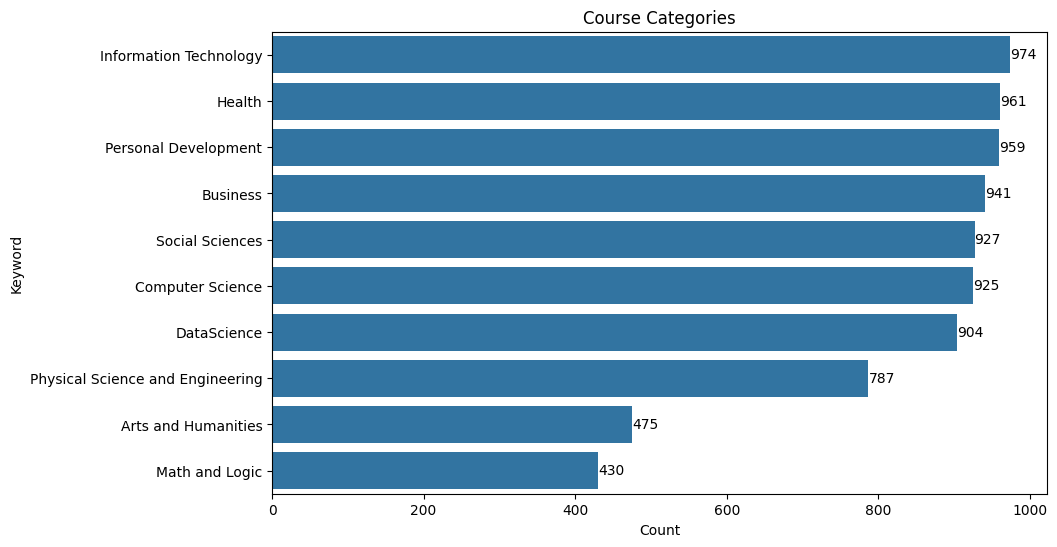

In [44]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=keyword_df,
    x='Count',
    y='Keyword'
)
ax.bar_label(ax.containers[0])

plt.title("Course Categories")
plt.show()

In [45]:
import ast

def safe_parse(x):

    if pd.isna(x):
        return []

    if isinstance(x, list):
        return x

    try:
        return ast.literal_eval(x)
    except:
        return []

df_clean['Skill gain'] = df_clean['Skill gain'].apply(safe_parse)

In [46]:
type(df_clean['Skill gain'].iloc[0])

list

In [47]:
empty_skills = (
    df_clean['Skill gain']
    .apply(len)
    .eq(0)
    .sum()
)

print(empty_skills)

2183


In [48]:
round(
    empty_skills /
    len(df_clean)
    * 100,
    2
)

np.float64(34.09)

### Skill Tag Completeness Analysis

Approximately 33.6% of courses contain no skill tags.

This indicates that a recommendation system based solely on skills would suffer from significant coverage limitations.

To address this issue, additional textual features such as course title, learning outcomes, category labels, institution names, and instructor information will be incorporated into the recommendation model.

In [49]:
import ast
import pandas as pd

def safe_parse(x):
    
    # Missing values
    if x is None:
        return []
    
    # Already a list
    if isinstance(x, list):
        return x
    
    # String representation of list
    if isinstance(x, str):
        
        x = x.strip()
        
        if x == "":
            return []
        
        try:
            parsed = ast.literal_eval(x)
            
            if isinstance(parsed, list):
                return parsed
            
            return [str(parsed)]
        
        except:
            return [x]
    
    # Everything else
    return []

# Columns to convert
list_columns = [
    'Skill gain',
    'Modules',
    'Instructor',
    'Offered By',
    'Keyword'
]

for col in list_columns:
    df_clean[col] = df_clean[col].apply(safe_parse)

# Verify
for col in list_columns:
    print(f"\n{col}")
    print(df_clean[col].apply(type).value_counts())


Skill gain
Skill gain
<class 'list'>    6404
Name: count, dtype: int64

Modules
Modules
<class 'list'>    6404
Name: count, dtype: int64

Instructor
Instructor
<class 'list'>    6404
Name: count, dtype: int64

Offered By
Offered By
<class 'list'>    6404
Name: count, dtype: int64

Keyword
Keyword
<class 'list'>    6404
Name: count, dtype: int64


In [50]:
institution_counts = (
    df_clean['Offered By']
    .apply(
        lambda x:
        x[0]
        if len(x)>0
        else "Unknown"
    )
    .value_counts()
    .head(15)
)

institution_counts

Offered By
Coursera Project Network                      505
University of Colorado Boulder                296
Google Cloud                                  264
Johns Hopkins University                      194
University of Michigan                        192
Google                                        182
IBM                                           173
University of Illinois at Urbana-Champaign    137
University of Pennsylvania                    137
University of Colorado System                 102
Arizona State University                      102
Universidad Nacional Autónoma de México        96
University of California, Irvine               88
Duke University                                84
Rice University                                76
Name: count, dtype: int64

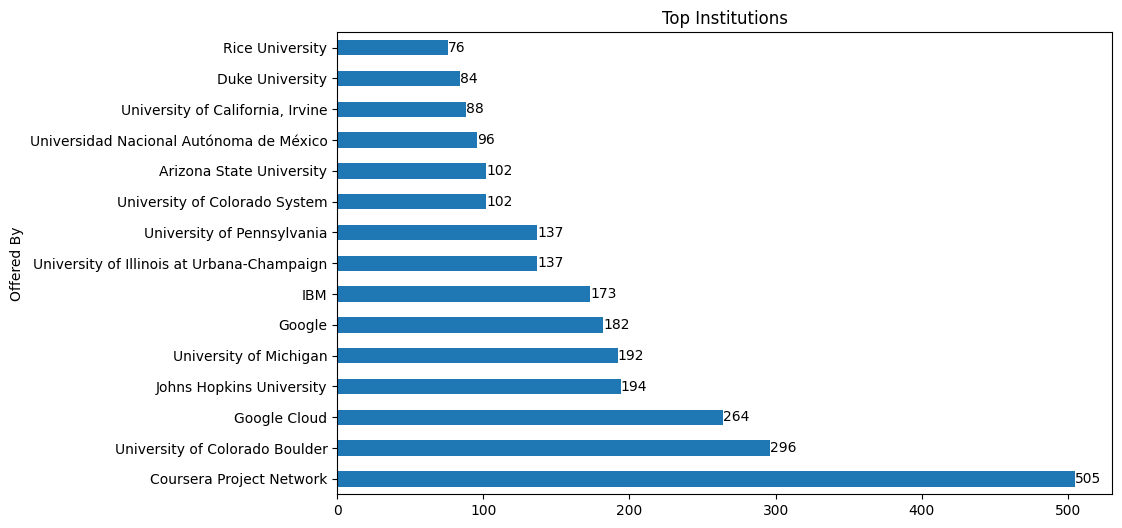

In [51]:
ax=institution_counts.plot(
    kind='barh',
    figsize=(10,6)
)
ax.bar_label(ax.containers[0])
plt.title("Top Institutions")
plt.show()

## Key EDA Findings

### Rating Distribution
- Ratings are highly skewed toward 4.5–5.0.(Left Skewed)
- Most courses have very high ratings.
- Rating alone is not sufficient for recommendations because many courses appear similarly rated.

### Course Level Distribution
- Beginner courses dominate the catalog (~72%).
- Intermediate courses represent a smaller segment.
- Advanced courses are rare.

### Category Distribution
- Social Sciences, Personal Development, Health, Computer Science, Business, Information Technology, and Data Science contain similar numbers of courses.
- The dataset is relatively balanced across major categories.

### Institution Distribution
- Coursera Project Network offers the largest number of courses.
- Google Cloud, University of Colorado Boulder, Johns Hopkins, Michigan, IBM, and Google are major contributors.

### Skill Completeness
- 33.6% of courses contain no skill tags.
- A recommendation engine cannot rely solely on skills and must incorporate additional metadata.

# Feature Engineering

To build a content-based recommendation engine, multiple course attributes are combined into a unified textual representation.

The following features are used:

- Course Title
- Learning Outcomes
- Skill Gain
- Keyword Categories
- Instructor
- Institution
- Level

This combined representation will later be transformed using TF-IDF vectorization.

In [52]:
df_clean['skills_text'] = (
    df_clean['Skill gain']
    .apply(lambda x: ' '.join(x))
)

df_clean['keywords_text'] = (
    df_clean['Keyword']
    .apply(lambda x: ' '.join(x))
)

df_clean['instructors_text'] = (
    df_clean['Instructor']
    .apply(lambda x: ' '.join(x))
)

df_clean['institution_text'] = (
    df_clean['Offered By']
    .apply(lambda x: ' '.join(x))
)

In [53]:
df_clean.sample(10)

,Course Title,Rating,Level,Duration,Review,What you will learn,Skill gain,Modules,Instructor,Offered By,Course Url,Keyword,duration_hours,review_count,skills_text,keywords_text,instructors_text,institution_text
5375,Speaking to persuade: Motivating audiences wit...,4.8,Beginner level,15 hours (approximately),306 reviews,,[],[Welcome. Let's develop a persuasive argument....,[Dr. Matt McGarrity],[University of Washington],https://www.coursera.org/learn/persuade-speech,[Personal Development],15,306,,Personal Development,Dr. Matt McGarrity,University of Washington
4790,Process Data from Dirty to Clean,4.8,Beginner level,26 hours (approximately),"14,008 reviews",Define different types of data integrity and i...,"[Spreadsheet, Data Integrity, Sample Size Dete...","[The importance of integrity, Clean data for m...",[Google Career Certificates],[Google],https://www.coursera.org/learn/process-data,[DataScience],26,14008,Spreadsheet Data Integrity Sample Size Determi...,DataScience,Google Career Certificates,Google
5183,Security Analyst Fundamentals Specialization,4.8,Beginner level,2 months at 10 hours a week,816 reviews,"Develop knowledge in digital forensics, incide...","[Computer Security Incident Management, Data B...","[Penetration Testing, Incident Response and Fo...",[IBM Skills Network Team],[IBM],https://www.coursera.org/specializations/secur...,[Information Technology],80,816,Computer Security Incident Management Data Bre...,Information Technology,IBM Skills Network Team,IBM
5976,Using APIs for Network Automation,4.7,Intermediate level,3 hours (approximately),NaN,,"[Json, Xml, Application Programming Interfaces...",[Course Introduction for Using APIs for Networ...,[Cisco Learning & Certifications],[Cisco Learning and Certifications],https://www.coursera.org/learn/using-apis-for-...,[Information Technology],3,0,Json Xml Application Programming Interfaces (A...,Information Technology,Cisco Learning & Certifications,Cisco Learning and Certifications
5983,Using Public Policy for Social Change,4.9,Beginner level,Approx. 14 hours to complete,14 reviews,Learn to identify and define each step of the ...,"[Policy Analysis, Problem Solving, Policy Desi...",[Week 1: What is Public Policy and What is it ...,[Paula Lantz],[University of Michigan],https://www.coursera.org/learn/using-public-po...,"[Health, DataScience, Social Sciences]",14,14,Policy Analysis Problem Solving Policy Design ...,Health DataScience Social Sciences,Paula Lantz,University of Michigan
846,Business Modeling Tools,4.7,Intermediate level,10 hours (approximately),NaN,,"[Microsoft Excel, Business Analytics, Business...","[Introduction to Business Modeling Tools, Intr...",[Alton Henley],[Howard University],https://www.coursera.org/learn/business-modeli...,[Business],10,0,Microsoft Excel Business Analytics Business Ca...,Business,Alton Henley,Howard University
2294,Exploring the Origins of Selfhood,4.7,Beginner level,18 hours (approximately),NaN,,[],[The Concept of Identity: Historical and Philo...,[Roger L Martinez],[University of Colorado System],https://www.coursera.org/learn/identity-motiva...,[Personal Development],18,0,,Personal Development,Roger L Martinez,University of Colorado System
1090,Cloud Top Ten Risks,4.6,Intermediate level,9 hours (approximately),16 reviews,,[],"[Overview of the Top Ten Risks, Cloud Risks 2,...",[Rick Smith],[University of Minnesota],https://www.coursera.org/learn/cloud-top-ten-r...,[Information Technology],9,16,,Information Technology,Rick Smith,University of Minnesota
6080,Western Religions & Ecology,5.0,Beginner level,Approx. 18 hours to complete,13 reviews,,"[Philosophy, conservation, Religion, Ecology]","[MODULE 1: Course Introduction, MODULE 2: Intr...","[John Grim, Mary Evelyn Tucker]",[Yale University],https://www.coursera.org/learn/western-religio...,[Personal Development],18,13,Philosophy conservation Religion Ecology,Personal Development,John Grim Mary Evelyn Tucker,Yale University
3033,How to Secure your Network Device using 

In [54]:
df_clean['content_soup'] = (
    
    df_clean['Course Title'].fillna('') + ' ' +
    
    df_clean['What you will learn'].fillna('') + ' ' +
    
    df_clean['skills_text'] + ' ' +
    
    df_clean['keywords_text'] + ' ' +
    
    df_clean['instructors_text'] + ' ' +
    
    df_clean['institution_text'] + ' ' +
    
    df_clean['Level']
)

# Remove Redundant Features

The original Duration and Review columns are retained from the cleaning phase.

For modeling, the engineered numerical features duration_hours and review_count are used instead.

In [55]:
df_clean = df_clean.drop(
    columns=['Duration', 'Review'],
    errors='ignore'
)

In [56]:
df_clean.to_pickle(
    "data/coursera_cleaned.pkl"
)

In [57]:
df_clean.to_csv(
    "data/CourseraDataset-clean.csv"
)